#### Task 1: Baseline Model
Implement a convolutional neural network to classify speech:
<li>
    <ol>Achieve an accuracy of at least 50% on the validation data set.</ol>
    <ol>Use appropriate regularisation strategies to reduce overfitting.</ol>
    <ol>Produce a confusion matrix to evaluate the results.</ol>
</li>

In [42]:
import torch
from torch import nn
import torch.nn.functional as F #For activation fns, loss fun etc.,
import torch.optim as optim #Optimization module
from torch.utils.data import DataLoader, Dataset
from torchinfo import summary #To display model architecture
from torch.utils.tensorboard  import SummaryWriter

import torchvision
from torchvision import datasets
from torchvision.transforms import v2 as transforms
from torchvision.ops import Conv2dNormActivation

from dataclasses import dataclass
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sn

import matplotlib.pyplot as plt
import numpy as np
import random
import time
import warnings
import os
from tqdm import tqdm

import pandas as pd
%matplotlib inline
warnings.filterwarnings("ignore")

In [43]:
from torchaudio.transforms import FrequencyMasking, TimeMasking

In [44]:
def set_seeds():
    """
    Sets a fixed seed value for reproducibility across multiple libraries (random, NumPy)
    This ensures that model training and results remain consistent across multiple runs.
    """
    SEED_VALUE = 42

    random.seed(SEED_VALUE)

    np.random.seed(SEED_VALUE)

    torch.manual_seed(SEED_VALUE)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED_VALUE) #Single GPU
        torch.cuda.manual_seed_all(SEED_VALUE) #Multiple GPU

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = True

set_seeds()

#### Download and Extract the Dataset 

In [3]:
# get the data from github and unzip
!wget https://raw.githubusercontent.com/andrsn/data/main/speechImageData.zip

# MAKE SURE YOU HAVE UPLOADED THE ZIP FILE
!unzip -q /content/speechImageData.zip

--2026-03-15 17:57:00--  https://raw.githubusercontent.com/andrsn/data/main/speechImageData.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9872924 (9.4M) [application/zip]
Saving to: ‘speechImageData.zip’

speechImageData.zip 100%[===================>]   9.42M  4.85MB/s    in 1.9s    

2026-03-15 17:57:03 (4.85 MB/s) - ‘speechImageData.zip’ saved [9872924/9872924]

unzip:  cannot find or open /content/speechImageData.zip, /content/speechImageData.zip.zip or /content/speechImageData.zip.ZIP.


#### Training Configuration Parameters

In [45]:
@dataclass(frozen=True)
class TrainingConfig:
    """Configuration for training"""
    batch_size: int = 64
    num_epochs: int = 50
    learning_rate: float = 1e-4

    log_interval: int = 1
    test_interval: int = 1
    data_root: int = "./speechImageData/speechImageData - Copy/"
    num_workers: int = 4 #number of thread involving in loading image
    deviec:str = 'cpu'

train_config = TrainingConfig()
DEVICE = torch.device("cuda") if torch.cuda.is_available() else "cpu"
print(f"Available device {DEVICE}")

Available device cpu


#### Load Custom data available in Pytorch

In [46]:
train_root = os.path.join(train_config.data_root, "TrainData")
val_root = os.path.join(train_config.data_root, "ValData")

#### Data Preprocessing

In [47]:
mean = [0.4193]  #mean and std of this speech data
std = [0.3362]

img_size = (98, 50)

preprocess = transforms.Compose([
    transforms.Resize(img_size, antialias=True),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

In [48]:
common_transform = transforms.Compose([
    preprocess,
    transforms.Normalize(mean, std)
])

train_transforms = transforms.Compose([
    preprocess,
    transforms.RandomApply([
        TimeMasking(time_mask_param=10),
        FrequencyMasking(freq_mask_param=5)
    ],p=0.9),
    transforms.Normalize(mean,std)
])

#### Data Loader Preparation

In [49]:
train_data = datasets.ImageFolder(root= train_root, transform=train_transforms)
val_data = datasets.ImageFolder(root= val_root, transform=common_transform)

train_data.classes

['background',
 'down',
 'go',
 'left',
 'no',
 'off',
 'on',
 'right',
 'stop',
 'unknown',
 'up',
 'yes']

In [50]:
train_loader = DataLoader(
    train_data,
    shuffle=True,
    batch_size= train_config.batch_size,
    num_workers = train_config.num_workers
)

val_loader = DataLoader(
    val_data,
    shuffle=False,
    batch_size= train_config.batch_size,
    num_workers= train_config.num_workers 
)

#### Display Images from the Dataset

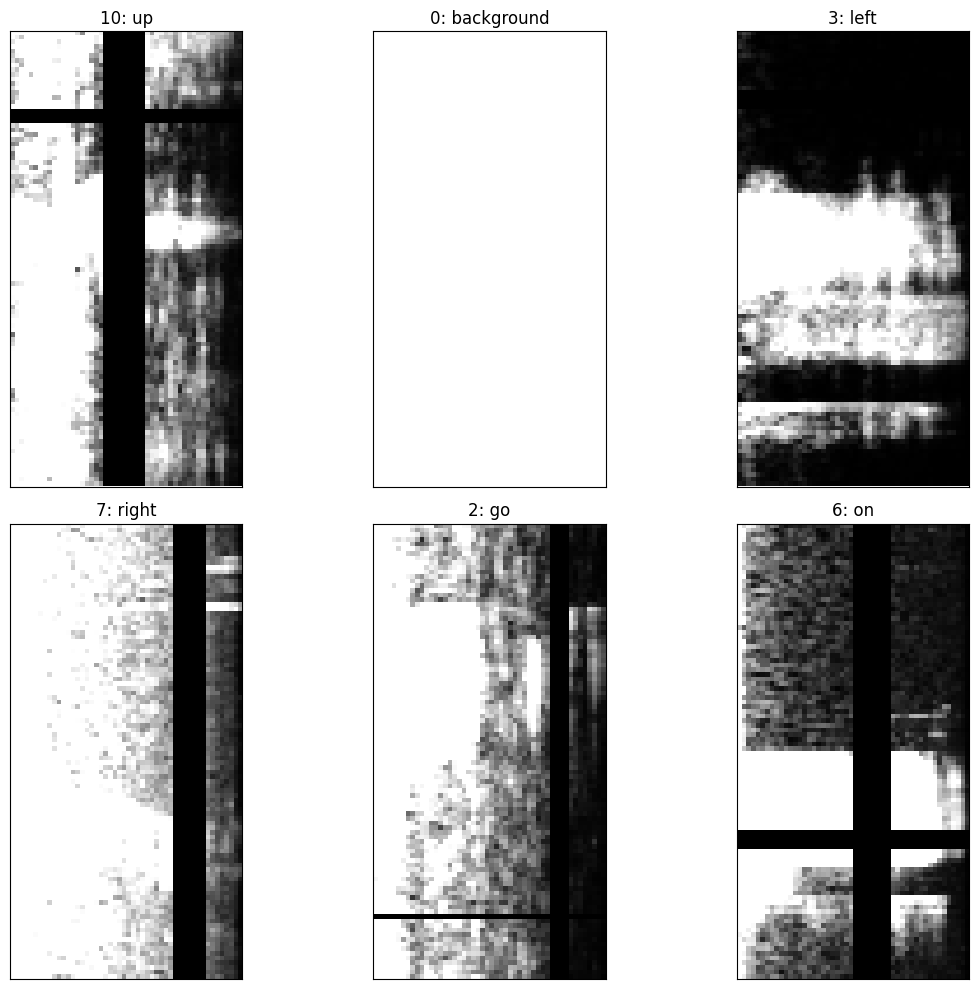

In [56]:
def visualize_images(trainloader, number_of_images=6):
    fig = plt.figure(figsize=(12,10))

    images, labels = next(iter(train_loader))

    num_rows = 2
    num_col = int(np.ceil(number_of_images/num_rows))

    for idx in range(min(number_of_images, len(images))):
        image, label = images[idx], labels[idx]

        #Create a subplot 
        ax = fig.add_subplot(num_rows, num_col, idx+1, xticks=[], yticks=[])

        image = image.squeeze()
        image = (image - image.min())/ (image.max() - image.min())
       
        ax.imshow(image, cmap='gray')

        ax.set_title(f"{label.item()}: {train_data.classes[label.item()]}")

    fig.tight_layout()

    plt.savefig("time_frequency_masking.pdf", dpi=600, bbox_inches="tight")
    plt.show()
visualize_images(train_loader)

#### CNN Model Implementation

In [57]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.base_num_filters = 32
        self.filter_size = 3

        self._model = nn.Sequential(
            #-------Convolution Layer-------
            nn.Conv2d(in_channels=1, out_channels=self.base_num_filters, kernel_size=self.filter_size),
            nn.BatchNorm2d(self.base_num_filters),
            nn.ReLU(inplace=True),

            nn.Conv2d(in_channels=self.base_num_filters, out_channels=self.base_num_filters, kernel_size=self.filter_size),
            nn.BatchNorm2d(self.base_num_filters),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(4,2), stride=(4,2)),

            #--------------
            nn.LazyConv2d(out_channels=self.base_num_filters*2, kernel_size=self.filter_size),
            nn.BatchNorm2d(self.base_num_filters*2),
            nn.ReLU(inplace=True),

            nn.LazyConv2d(out_channels=self.base_num_filters*2, kernel_size=self.filter_size),
            nn.BatchNorm2d(self.base_num_filters*2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(4,2), stride=(4,2)),
            #-------Feedforward---------
            nn.LazyConv2d(out_channels=self.base_num_filters*2*2, kernel_size=self.filter_size),
            nn.BatchNorm2d(self.base_num_filters*2*2),
            nn.ReLU(inplace=True),
            
            nn.AdaptiveMaxPool2d(output_size=(3,3)),

            #-------Flatten------------
            nn.Flatten(),

            #------Classification------
            nn.Linear(in_features=self.base_num_filters*2*2*3*3, out_features=256),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(in_features=256, out_features=12)   
        )
        
    def forward(self, x):
        return self._model(x)

In [66]:
model = Model()

#optimizer = torch.optim.Adam(model.parameters(), lr= train_config.learning_rate)
optimizer = torch.optim.Adam(model.parameters(), lr= train_config.learning_rate, weight_decay=.1)

logdir = "runs/80epoch-3.3M_param_dropout"

writer = SummaryWriter(logdir)

dummy_input = (1,1,98,50)

print(summary(model, dummy_input, row_settings=["var_names"], device='cpu'))

Layer (type (var_name))                  Output Shape              Param #
Model (Model)                            [1, 12]                   --
├─Sequential (_model)                    [1, 12]                   --
│    └─Conv2d (0)                        [1, 32, 96, 48]           320
│    └─BatchNorm2d (1)                   [1, 32, 96, 48]           64
│    └─ReLU (2)                          [1, 32, 96, 48]           --
│    └─Conv2d (3)                        [1, 32, 94, 46]           9,248
│    └─BatchNorm2d (4)                   [1, 32, 94, 46]           64
│    └─ReLU (5)                          [1, 32, 94, 46]           --
│    └─MaxPool2d (6)                     [1, 32, 23, 23]           --
│    └─Conv2d (7)                        [1, 64, 21, 21]           18,496
│    └─BatchNorm2d (8)                   [1, 64, 21, 21]           128
│    └─ReLU (9)                          [1, 64, 21, 21]           --
│    └─Conv2d (10)                       [1, 64, 19, 19]           36,928
│ 

#### Model Training and Evaluation

In [67]:
def train(model, trainloader, optimizer, DEVICE):

    #set model to training mode
    model.train()

    #Move model to specified device
    model.to(DEVICE)

    running_loss = 0

    correct_prediction = 0

    total_samples = 0

    for images, labels in tqdm(train_loader, desc="Training"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        #Reset to zero
        optimizer.zero_grad()

        #Forward pass
        outputs = model(images)

        loss = F.cross_entropy(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, dim=1)

        total_samples += labels.size(0)

        correct_prediction += (predicted == labels).sum().item()

    avg_loss = running_loss / len(trainloader)

    accuracy = 100 * correct_prediction/ total_samples

    return avg_loss, accuracy

In [68]:
def validation(model, val_loader, DEVICE):
    model.eval()
    model.to(DEVICE)

    running_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)

            loss = F.cross_entropy(outputs, labels)

            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, dim=1)
            
            total_samples += labels.size(0)
            
            correct_predictions += (predicted == labels).sum().item()
            
        avg_loss = running_loss / len(val_loader)

        accuracy = 100 * correct_predictions/ total_samples

    return avg_loss, accuracy 

In [69]:
def main(model, trainloader, val_loader, DEVICE='cpu'):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    best_val_accuracy = 0.0
    best_weights = None

    for epoch in range(train_config.num_epochs):
        train_loss, train_accuracy = train(model,trainloader, optimizer, DEVICE)
        val_loss, val_accuracy = validation(model, val_loader, DEVICE)

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1} - Train loss: {train_loss} Train accuracy: {train_accuracy} %%% Val loss: {val_loss} Val accuracy: {val_accuracy}")

        writer.add_scalar('Loss/train', train_loss)
        writer.add_scalar('Loss/val', val_loss)
        writer.add_scalar('Accuracy/train', train_accuracy)
        writer.add_scalar('Accuracy/val', val_accuracy)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_weights = model.state_dict()
            print("Saving the model... ")
            torch.save(best_weights, "best.pt")
            

    return train_losses, val_losses, train_accuracies, val_accuracies
    

In [70]:
train_losses, val_losses, train_accuracies, val_accuracies = main(model, train_loader, val_loader, 'cpu')

Validation: 100%|███████████████████████████████| 19/19 [00:01<00:00, 10.21it/s]


Epoch 1 - Train loss: 2.297531247138977 Train accuracy: 20.089955022488756 %%% Val loss: 2.7652670270518254 Val accuracy: 5.123825789923143
Saving the model... 


Validation: 100%|███████████████████████████████| 19/19 [00:01<00:00,  9.72it/s]


Epoch 2 - Train loss: 2.112798009067774 Train accuracy: 26.58670664667666 %%% Val loss: 2.3344117653997323 Val accuracy: 22.28864218616567
Saving the model... 


Validation: 100%|███████████████████████████████| 19/19 [00:01<00:00,  9.91it/s]


...

Epoch 48 - Train loss: 0.34712031157687306 Train accuracy: 93.75312343828087 %%% Val loss: 1.236112122080828 Val accuracy: 60.37574722459436


Validation: 100%|███████████████████████████████| 19/19 [00:01<00:00,  9.50it/s]


Epoch 49 - Train loss: 0.3473175666294992 Train accuracy: 94.05297351324337 %%% Val loss: 1.132438310667088 Val accuracy: 65.15798462852263


Validation: 100%|███████████████████████████████| 19/19 [00:02<00:00,  9.23it/s]

Epoch 50 - Train loss: 0.34325379226356745 Train accuracy: 94.05297351324337 %%% Val loss: 1.1485239322248257 Val accuracy: 63.877028181041844


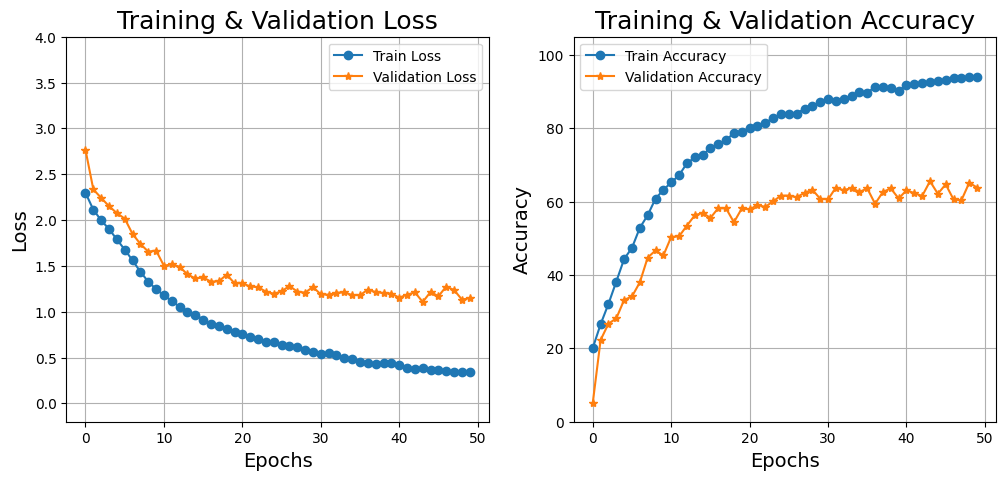

In [71]:
FONT_SIZE = 14
TITLE_SIZE = 18
X_LABEL_SIZE = 14
Y_LABEL_SIZE = 14
LEGEND_SIZE = 10

PLOT_FILE = "task_1_with_regularization.pdf"

plt.figure(figsize=[12,5])

plt.subplot(1,2,1)
plt.plot(range(0,len(train_losses)), train_losses, label="Train Loss", marker='o')
plt.plot(range(0,len(train_losses)), val_losses, label="Validation Loss", marker='*')

plt.ylim([-0.2,4])
plt.xlabel("Epochs", fontsize=X_LABEL_SIZE)
plt.ylabel("Loss", fontsize=Y_LABEL_SIZE)
plt.title("Training & Validation Loss", fontsize=TITLE_SIZE)
plt.grid()

plt.legend()

plt.subplot(1,2,2)
plt.plot(range(0,len(train_accuracies)), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(0,len(val_accuracies)), val_accuracies, label="Validation Accuracy", marker='*')

plt.ylim([0,105])
plt.xlabel("Epochs", fontsize=X_LABEL_SIZE)
plt.ylabel("Accuracy", fontsize=Y_LABEL_SIZE)
plt.title("Training & Validation Accuracy", fontsize=TITLE_SIZE)

plt.legend()

plt.grid()

plt.savefig(PLOT_FILE, dpi=600, bbox_inches="tight")

#### Confusion Matrix

In [72]:
def prediction(model, val_loader):

    model.eval()
    model.to(DEVICE)

    all_images, all_labels = [], []
    all_pred_indices, all_pred_probs = [], []

    for images, labels in val_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        with torch.inference_mode():
             outputs = model(images)

        prob = F.softmax(outputs,dim=1)
        pred_indices = prob.data.max(dim=1)[1]
        pred_probs = prob.data.max(dim=1)[0]

        all_images.append(images.cpu())
        all_labels.append(labels.cpu())
        all_pred_indices.append(pred_indices.cpu())
        all_pred_probs.append(pred_probs.cpu())


    return (torch.cat(all_images).numpy(),
            torch.cat(all_labels).numpy(),
            torch.cat(all_pred_indices).numpy(),
            torch.cat(all_pred_probs).numpy())

In [73]:
model.load_state_dict(torch.load("best.pt"))
val_images, val_gt_labels, pred_indices, pred_probs = prediction(model, val_loader)

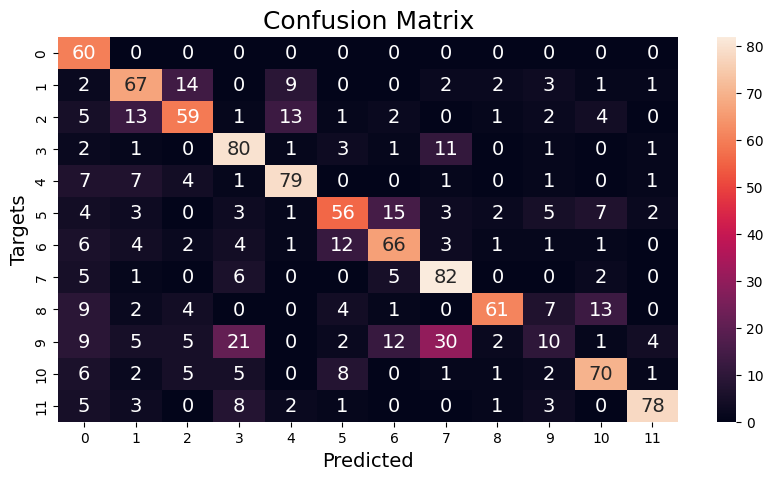

In [77]:
cm = confusion_matrix(y_true=val_gt_labels, y_pred = pred_indices)

plt.figure(figsize= [10,5])
sn.heatmap(cm, annot=True, fmt='d', annot_kws={"size":14})
plt.xlabel("Predicted", fontsize=X_LABEL_SIZE)
plt.ylabel("Targets", fontsize=Y_LABEL_SIZE)
plt.title(f"Confusion Matrix", fontsize=TITLE_SIZE)
plt.savefig("Confusion_Matrix.pdf", dpi=600, bbox_inches="tight")
plt.show()